# Second-order geometry: principal subspace and full covariance

Slide metrics in **4096-d ambient** (no PCA-32 rank plot):

$$\mathrm{SubSim}_{32} = \frac{1}{32}\left\|\big(U_{\mathrm{real}}^{(32)}\big)^\top U_{\mathrm{gen}}^{(32)}\right\|_F^2 \in [0,1]$$

$$D_{\mathrm{cov}} = \frac{\|\Sigma_{\mathrm{real}}-\Sigma_{\mathrm{gen}}\|_F}{\|\Sigma_{\mathrm{real}}\|_F}$$

Compared against diffusion samples (1024 / 8196) and three training-set Gaussians plus $\mathcal{N}(0,I)$.

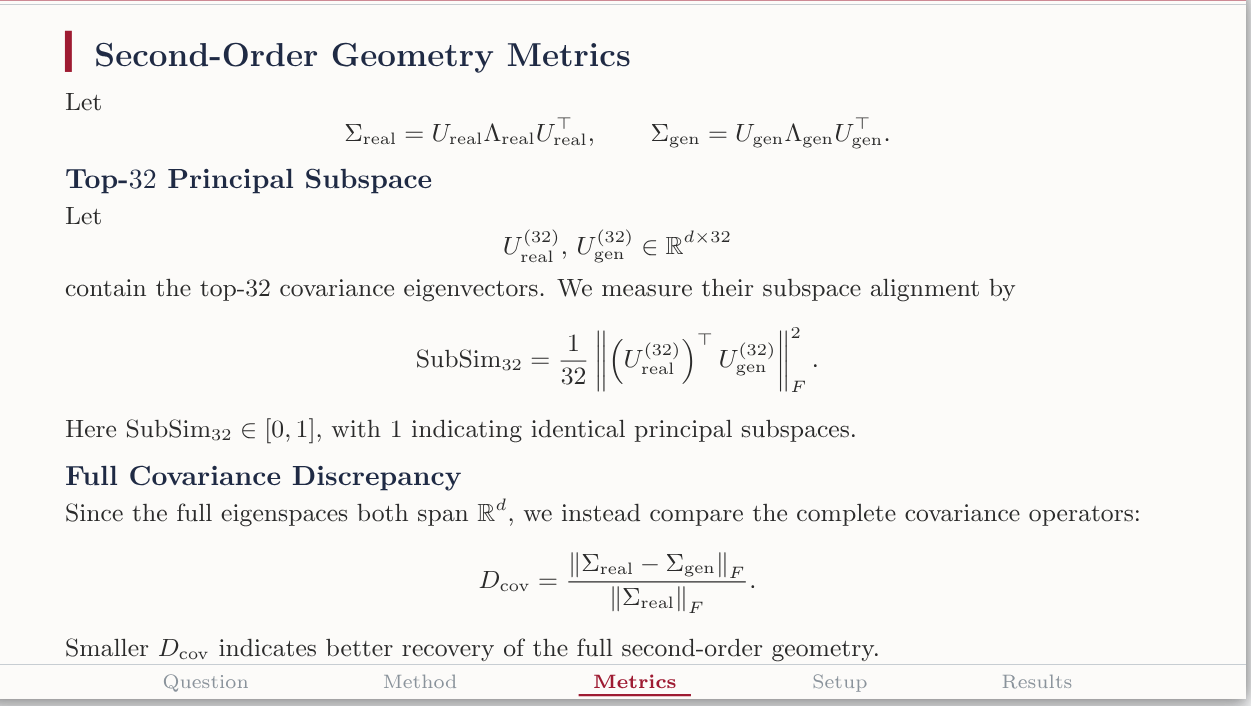

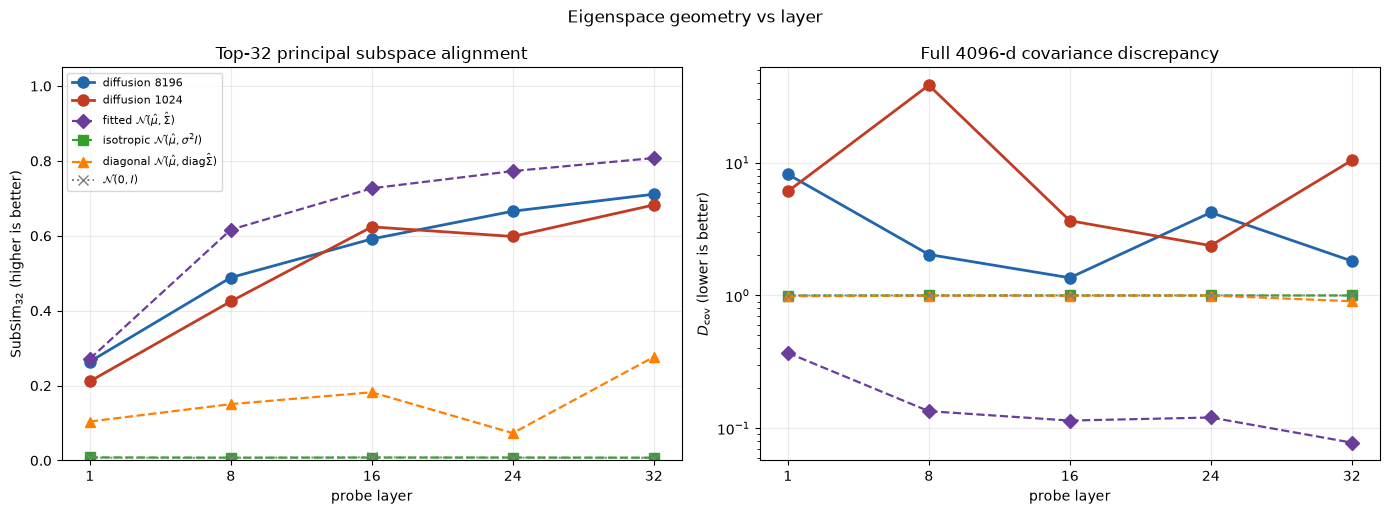

layer  S32-1024  S32-8196  S32-fit   D-1024   D-8196    D-fit
    1     0.211     0.264    0.271    6.079    8.188    0.370
    8     0.425     0.489    0.616   38.354    2.034    0.134
   16     0.624     0.592    0.727    3.657    1.359    0.114
   24     0.598     0.666    0.773    2.373    4.219    0.120
   32     0.682     0.711    0.808   10.417    1.818    0.078


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
FIGS = ROOT / "notebooks" / "figs"
LAYERS = [1, 8, 16, 24, 32]
geom = json.loads((FIGS / "geom_metrics.json").read_text())
x = np.arange(len(LAYERS))

STYLE = {
    "8196": dict(color="#2166ac", marker="o", lw=2.0, ms=8, label=r"diffusion 8196"),
    "1024": dict(color="#c23b22", marker="o", lw=2.0, ms=8, label=r"diffusion 1024"),
    "fitted": dict(color="#6a3d9a", marker="D", lw=1.6, ms=7, ls="--",
                   label=r"fitted $\mathcal{N}(\hat\mu,\hat\Sigma)$"),
    "isotropic": dict(color="#33a02c", marker="s", lw=1.6, ms=7, ls="--",
                      label=r"isotropic $\mathcal{N}(\hat\mu,\sigma^2 I)$"),
    "diagonal": dict(color="#ff7f00", marker="^", lw=1.6, ms=7, ls="--",
                     label=r"diagonal $\mathcal{N}(\hat\mu,\mathrm{diag}\hat\Sigma)$"),
    "n01": dict(color="#7f7f7f", marker="x", lw=1.4, ms=7, ls=":",
                label=r"$\mathcal{N}(0,I)$"),
}

def series(key):
    if key in ("1024", "8196"):
        return [geom["layers"][str(l)]["diffusion"][key] for l in LAYERS]
    return [geom["layers"][str(l)]["baselines"][key] for l in LAYERS]

def plot_metric(ax, metric, ylabel, title, logy=False):
    for key, st in STYLE.items():
        ys = [row[metric] for row in series(key)]
        ax.plot(x, ys, **st)
    ax.set_xticks(x, [str(l) for l in LAYERS])
    ax.set_xlabel("probe layer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    if logy:
        ax.set_yscale("log")

display(Image(filename=str(FIGS / "slide_eigenspace.png")))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
plot_metric(axes[0], "subsim32", r"$\mathrm{SubSim}_{32}$ (higher is better)",
            "Top-32 principal subspace alignment")
plot_metric(axes[1], "dcov", r"$D_{\mathrm{cov}}$ (lower is better)",
            "Full 4096-d covariance discrepancy", logy=True)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Eigenspace geometry vs layer")
fig.tight_layout()
fig.savefig(FIGS / "eigenspace.png", dpi=160)
fig.savefig(FIGS / "eigenspace.pdf")
fig.savefig(ROOT / "notebooks" / "eigenspace.pdf")
plt.show()

print(f"{'layer':>5} {'S32-1024':>9} {'S32-8196':>9} {'S32-fit':>8} {'D-1024':>8} {'D-8196':>8} {'D-fit':>8}")
for l in LAYERS:
    a = geom["layers"][str(l)]
    print(f"{l:>5} {a['diffusion']['1024']['subsim32']:>9.3f} {a['diffusion']['8196']['subsim32']:>9.3f} "
          f"{a['baselines']['fitted']['subsim32']:>8.3f} {a['diffusion']['1024']['dcov']:>8.3f} "
          f"{a['diffusion']['8196']['dcov']:>8.3f} {a['baselines']['fitted']['dcov']:>8.3f}")
